<a href="https://colab.research.google.com/github/MDankloff/Delayed-Fairness-Project/blob/main/BAF_TryOut_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAF calibrated version of cloned_ltf_pop.

same pipeline: generator/ simulator/ fair_model / baseline / utils / evaluation (LR, LCF, EO, DP)

same run and evaluate () workflow only the data source is BAF and the Banks ground truth bias change.

Sensitive attribute: income (split at 0.6 income), not age.
generator (k_same/k_other) thus works same.

In [4]:
#[Cell] Clone / mount, same as cloned_ltf_pop
import os
import sys

repo_url = "https://github.com/MDankloff/Delayed-Fairness-Project.git"
repo_dir = "/content/Delayed-Fairness-Project"

if not os.path.exists(repo_dir):
    os.system(f"git clone {repo_url} {repo_dir}")
else:
    os.system(f"git -C {repo_dir} pull origin main")

src_path = os.path.join(repo_dir, "Synthetic", "src")   # capital S
assert os.path.exists(os.path.join(src_path, "generator.py")), \
    f"generator.py not found at {src_path} -- check the clone succeeded"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Using:", src_path)


Using: /content/Delayed-Fairness-Project/Synthetic/src


# Libraries

In [5]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

import generator as gen_mod #gen_multi_steps_profiles lives only here
from generator import Agent as GenAgentBase        # used for the training-data bootstrap
from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#!pip install mesa pandas scikit-learn networkx
#!pip install mesa==1.2.1
#from mesa import Model, Agent
#from mesa.time import RandomActivation
#from collections import defaultdict

# Load BAF data

Saved parquet files from csv

In [6]:
from google.colab import drive
drive.mount('/content/drive')
!cd '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF'

Mounted at /content/drive


In [7]:
base_path = '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF/parquet data'

extension = "parquet" #parquet for smaller files, csv available
data_paths = glob.glob(f"{base_path}/*.{extension}")

def read_dataset(path, ext = extension):
    if ext == "csv":
      return pd.read_csv(path)
    elif ext == "parquet":
      return pd.read_parquet(path)
    else:
      raise ValueError(f"Unsupported file extension: {ext}")

# Extract variant name from the file path (without the extension)
def get_variant(path):
    return os.path.basename(path).split(".")[0]

# Dictionary comprehension to read all CSV files into a dictionary of DataFrames
dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}
print(f"Loaded datasets: {list(dataframes.keys())}")

datasets_paths = {
    "Base": base_path + "/Base.parquet", # sampled to best represent original dataset
    "Variant I": base_path + "/Variant I.parquet", # higher group size disparity than base - reducing the size of the minority group from approx 20 - 10% of the dataset
    "Variant II": base_path + "/Variant II.parquet", # higher prevalence disparity than base - one group has 5 x the fraud detection rate of the other while group sizes are equal
    "Variant III": base_path + "/Variant III.parquet", # better separability for one of the groups
    "Variant IV": base_path + "/Variant IV.parquet", # higher prevalence disparity in train
    "Variant V": base_path + "/Variant V.parquet", # better separability in train for one of the groups
}

Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


In [9]:
#Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

#for better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

#df4 = variant4 #set to preferred variant
#new_df4 = df4.copy()

base_df = base.copy() #set to preferred variant, natural bias, no the sensitivy-test variant, used for calibration

# Explore Data

In [10]:
#print(f"base_df: {len(base_df):,} rows")

base_df: 1,000,000 rows


In [11]:
#make a simplified df containing only a few features
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score']].copy()
#df4_simple['month'].unique()

In [12]:
# Display descriptive statistics for the 'income' column
display(base_simple['income'].describe())

,income
count,1000000.000000
mean,0.562696
std,0.290343
min,0.100000
25%,0.300000
50%,0.600000
75%,0.800000
max,0.900000


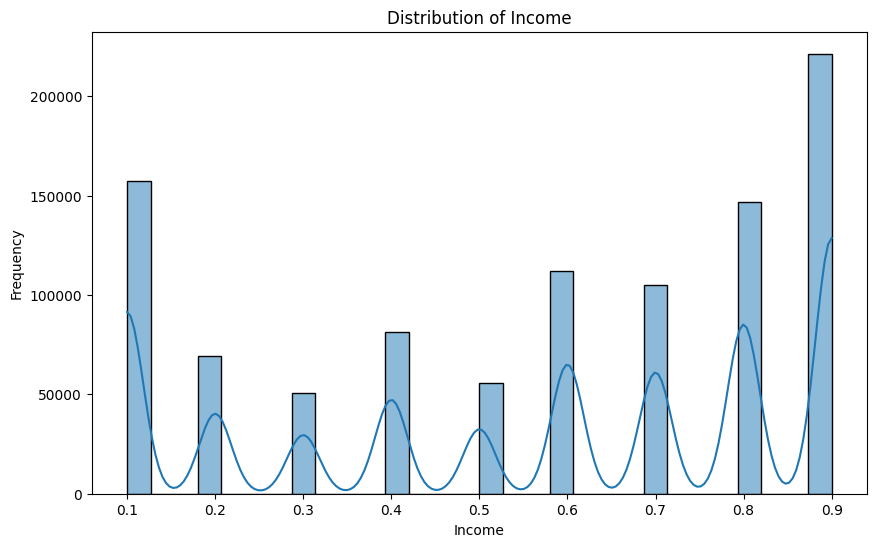

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(base_simple['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

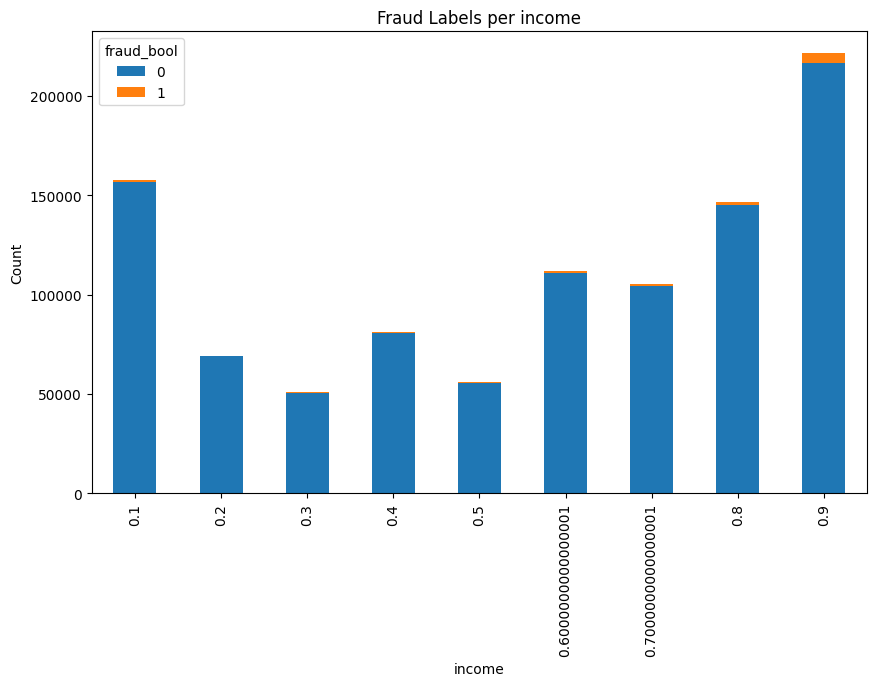

In [14]:
#fraud per income
fraud_per_month = base_simple.groupby(['income','fraud_bool']).size().unstack()
fraud_per_month.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels per income')
plt.xlabel('income')
plt.ylabel('Count')
plt.show()

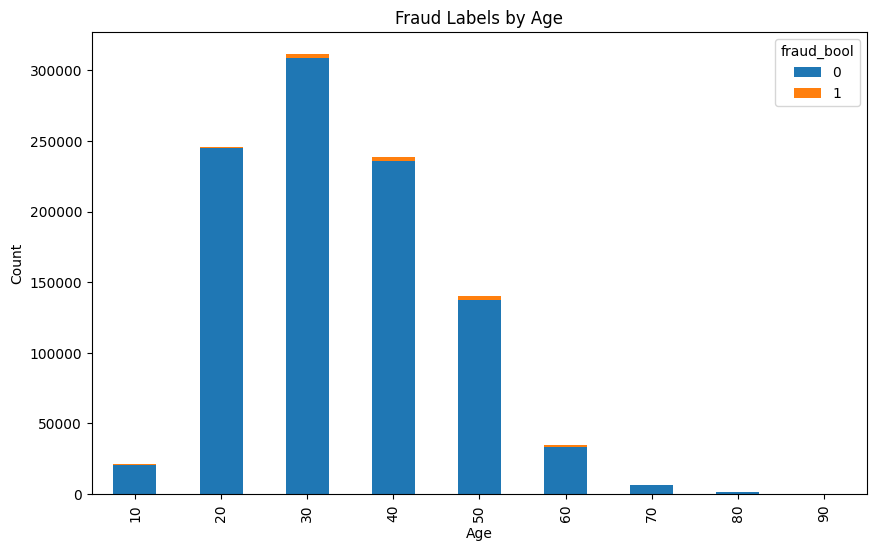

In [15]:
#fraud per age
fraud_per_age = base_simple.groupby(['customer_age','fraud_bool']).size().unstack()
fraud_per_age.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [16]:
print(base_simple.iloc[0])

fraud_bool             0.0
customer_age          40.0
income                 0.3
credit_risk_score    163.0
Name: 0, dtype: float64


In [18]:
print(base_simple['income'].value_counts())
print(base_simple.groupby('income')['fraud_bool'].mean())

income
0.9    221419
0.1    157449
0.8    146650
0.6    111973
0.7    105109
0.4     81364
0.2     69345
0.5     55858
0.3     50833
Name: count, dtype: int64
income
0.1    0.005773
0.2    0.006316
0.3    0.006649
0.4    0.007337
0.5    0.007949
0.6    0.008779
0.7    0.008819
0.8    0.010924
0.9    0.021638
Name: fraud_bool, dtype: float64


In [22]:
base_simple.groupby('customer_age')['income'].mean()   # mean income by age group
# or
pd.crosstab(base_simple['customer_age'], base_simple['income'])

income,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
customer_age,,,,,,,,,
10,6359,2147,1379,1961,1171,2092,1722,1995,2161
20,51642,20781,14617,22527,14718,28382,24663,31377,37148
30,46607,21303,15954,25519,17673,35632,33592,46726,68427
40,28198,13751,10407,17294,12402,25884,26043,38445,66288
50,18051,8454,6381,10662,7464,15246,14660,21741,37694
60,5327,2342,1711,2780,1994,3829,3613,5185,7989
70,1040,470,308,513,355,775,674,966,1416
80,214,92,72,101,74,125,135,203,281
90,11,5,4,7,7,8,7,12,15


# Create demographic groups

Make exact 50/50 income split to get even split populations (not same as group split for graph).

income is decile-bucketed [0.1...0.9] in steps of 0.1, a huge nr of rows are at same median value.
A > or >= threshold throws that whole tied block to one side and breaks the balance. confirmed on the real data: `income > 0.600` gives 585,151 High / 414,849 Low (58.5% / 41.5%), not 50/50.

Fix: strictly-above -> High(1), strictly-below -> Low(0), and only the
tied-at-median block gets randomly split to make up the exact difference
(seeded, so reproducible). Confirmed on real Base data this gives an
exact 500,000 / 500,000 split with fraud rates 0.694% (Low) vs 1.512%
(High) -- a ~2.18x ratio, which is what Bank.params gets calibrated against below

In [25]:
def make_balanced_group(df, col, seed=42):
    """Return a 0/1 numpy array: exact 50/50 split of df[col], ties at the
    median broken randomly (reproducibly) rather than all going one way."""
    median_val = df[col].median()
    above = df[col] > median_val
    below = df[col] < median_val
    tied = df[col] == median_val

    n_total = len(df)
    target_high = n_total // 2
    n_needed_from_tied = max(0, target_high - above.sum())

    rng = np.random.default_rng(seed)
    tied_idx = df.index[tied].to_numpy()
    rng.shuffle(tied_idx)
    high_tied_idx = set(tied_idx[:n_needed_from_tied])

    group = np.where(
        above, 1,
        np.where(below, 0,
                 np.where(df.index.isin(high_tied_idx), 1, 0))
    ).astype(int)
    return group, median_val

In [26]:
base_simple['S'], median_income = make_balanced_group(base_df, 'income', seed=42)
print(f"Median income: {median_income}")
print(pd.Series(base_df['S']).value_counts())   # should be exactly 500,000 / 500,000

rate_low = base_df.loc[base_df.S == 0, 'fraud_bool'].mean()
rate_high = base_df.loc[base_df.S == 1, 'fraud_bool'].mean()
print(f"Fraud rate  S=0 (lower income): {rate_low*100:.3f}%")
print(f"Fraud rate  S=1 (higher income): {rate_high*100:.3f}%")
print(f"Rate ratio: {max(rate_low,rate_high)/min(rate_low,rate_high):.3f}x")


Median income: 0.6000000000000001
S
0    500000
1    500000
Name: count, dtype: int64
Fraud rate  S=0 (lower income): 0.694%
Fraud rate  S=1 (higher income): 1.512%
Rate ratio: 2.179x


fraud-rate gap by income: the nr Bank.params gets - calibrated against below.

<Axes: xlabel='income'>

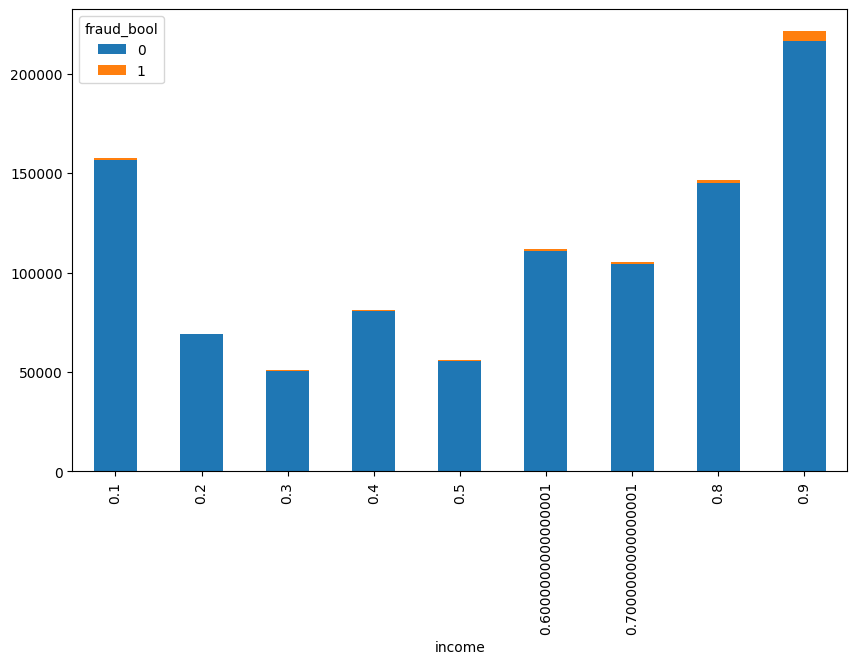

In [28]:
fraud_income_low=base_simple.groupby(['income','fraud_bool']).size().unstack()
fraud_income_low.plot(kind='bar', stacked=True, figsize=(10, 6))

In [31]:
base_simple['customer_age'] = np.where(base_df['customer_age'] >= 50, 'Older', 'Younger')
print(pd.crosstab(base_df['customer_age'], base_df['S']))


S                  0       1
customer_age                
10             14592    6395
20            145844  100011
30            154085  157348
40            101782  136930
50             62670   77683
60             17062   17708
70              3283    3234
80               640     657
90                42      34


# Make Feature Matrix for each applicant

Make feature matrix X: Each applicant i has a binary protected attribute S ∈ {0, 1} (e.g., age), a vector of dynamic features Xt ∈ Rd (e.g., credit risk score at time t), and a ground-truth label Yi,t ∈ {−1, 1} indicating whether the applicant can pay back (Yi,t =1) or default (Yi,t = −1).

In [32]:
#  Build feature matrix X a sensitive feature, a dynamic feature and the fraud bool (S, X_t = credit risk score, Y).
# Bank.params shrinks from 4 values [w_s, w_x1, w_x2, w_intercept] to 3: [w_s, w_x, w_intercept]

X_COLS = ['credit_risk_score']
X_all = base_df[X_COLS].to_numpy(dtype=float)
X_all = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)   # z-score
s_all = base_df['S'].to_numpy(dtype=int)
y_all = base_df['fraud_bool'].to_numpy(dtype=int)

assert X_all.shape[1] == 1, "X_t should be a single feature (credit risk score), per the model definition"